#0. Import and Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, make_scorer
)
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130

# ── CONFIGURATION ────────────────────────────────────────────
SEED       = 42
DATA_PATH  = "/content/drive/MyDrive/FakeReviewProject/"
EXP_PATH   = DATA_PATH + "experiment_b1/"
MODEL_PATH = EXP_PATH  + "models/"

os.makedirs(MODEL_PATH, exist_ok=True)
np.random.seed(SEED)

# Explicit fake-class F1 scorer for GridSearchCV
f1_fake_scorer = make_scorer(f1_score, pos_label=1)

# Metadata columns
# review_year deliberately excluded — proxy for time drift,
# not a genuine fake review signal
META_COLS = [
    "rating",
    "review_length",
    "extreme_rating",
    "review_month",
    "review_dayofweek",
    "is_weekend",
]

# ============================================================
# 1. LOAD AND FILTER DATA
# ============================================================

In [3]:
print("=" * 60)
print("1. LOADING AND FILTERING DATA")
print("=" * 60)

df_full = pd.read_csv(DATA_PATH + "yelp_nyc_processed_v2.csv",
                      parse_dates=["review_date"])
df_full = df_full.reset_index(drop=True)

print(f"Unfiltered shape : {df_full.shape}")
vc_full = df_full["label"].value_counts()
print(f"Unfiltered class distribution:")
print(f"  Genuine (0) : {vc_full[0]:,} ({vc_full[0]/len(df_full)*100:.1f}%)")
print(f"  Fake    (1) : {vc_full[1]:,} ({vc_full[1]/len(df_full)*100:.1f}%)")

# ── Iterative filtering ───────────────────────────────────────
# Remove reviewers AND products with <= 3 reviews iteratively
# until dataset size converges. This is required to compute
# meaningful behavioral features (burstiness, early review
# ratio, content similarity) in Experiment B2.
# B1 applies the same filter without behavioral features —
# this isolates the filtering effect from the feature effect.
#
# Threshold > 3 means keep only reviewers/products that have
# MORE THAN 3 reviews (i.e. at least 4).
print("\nApplying iterative filter (threshold > 3)...")

df = df_full.copy()
iteration = 0
while True:
    n_before = len(df)

    # Remove reviewers with <= 3 reviews
    reviewer_counts = df["reviewer_id"].value_counts()
    df = df[df["reviewer_id"].isin(
        reviewer_counts[reviewer_counts > 3].index
    )]

    # Remove products with <= 3 reviews
    product_counts = df["product_id"].value_counts()
    df = df[df["product_id"].isin(
        product_counts[product_counts > 3].index
    )]

    iteration += 1
    n_after = len(df)
    print(f"  Iteration {iteration}: {n_before:,} → {n_after:,} "
          f"(removed {n_before - n_after:,})")

    # Stop when no more rows are removed
    if n_after == n_before:
        break

df = df.reset_index(drop=True)

print(f"\nFiltered shape : {df.shape}")
vc = df["label"].value_counts()
print(f"Filtered class distribution:")
print(f"  Genuine (0) : {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  Fake    (1) : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")

# Report what filtering cost
fake_lost = vc_full[1] - vc[1]
pct_lost  = fake_lost / vc_full[1] * 100
print(f"\nFiltering cost:")
print(f"  Fake reviews lost : {fake_lost:,} ({pct_lost:.1f}% of all fake)")
print(f"  Total reviews lost: {len(df_full) - len(df):,}")
print(f"  Unique reviewers  : {df['reviewer_id'].nunique():,}")
print(f"  Unique products   : {df['product_id'].nunique():,}")

# Schema check
required = ["label", "text_clean"] + META_COLS
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
print("\nSchema check passed")

1. LOADING AND FILTERING DATA
Unfiltered shape : (359052, 13)
Unfiltered class distribution:
  Genuine (0) : 322,167 (89.7%)
  Fake    (1) : 36,885 (10.3%)

Applying iterative filter (threshold > 3)...
  Iteration 1: 359,052 → 172,395 (removed 186,657)
  Iteration 2: 172,395 → 172,389 (removed 6)
  Iteration 3: 172,389 → 172,389 (removed 0)

Filtered shape : (172389, 13)
Filtered class distribution:
  Genuine (0) : 167,488 (97.2%)
  Fake    (1) : 4,901 (2.8%)

Filtering cost:
  Fake reviews lost : 31,984 (86.7% of all fake)
  Total reviews lost: 186,663
  Unique reviewers  : 19,046
  Unique products   : 918

Schema check passed


# ============================================================
# 2. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

In [4]:
print("\n" + "=" * 60)
print("2. TRAIN / VALIDATION / TEST SPLIT (FROZEN)")
print("=" * 60)

if os.path.exists(MODEL_PATH + "idx_train.npy"):
    print("Loading existing splits...")
    idx_train = np.load(MODEL_PATH + "idx_train.npy")
    idx_val   = np.load(MODEL_PATH + "idx_val.npy")
    idx_test  = np.load(MODEL_PATH + "idx_test.npy")
else:
    raise RuntimeError("Split files missing — do NOT regenerate")

y       = df["label"].values
y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]


2. TRAIN / VALIDATION / TEST SPLIT (FROZEN)
Loading existing splits...


# ============================================================
# 3. TF-IDF FEATURES
# ============================================================

In [5]:
TFIDF_VEC_CACHE   = MODEL_PATH + "tfidf_vectorizer.pkl"
TFIDF_TRAIN_CACHE = MODEL_PATH + "X_tfidf_train.npz"
TFIDF_VAL_CACHE   = MODEL_PATH + "X_tfidf_val.npz"
TFIDF_TEST_CACHE  = MODEL_PATH + "X_tfidf_test.npz"

if all(os.path.exists(p) for p in [
    TFIDF_VEC_CACHE,
    TFIDF_TRAIN_CACHE,
    TFIDF_VAL_CACHE,
    TFIDF_TEST_CACHE
]):
    print("Loading cached TF-IDF...")
    tfidf         = joblib.load(TFIDF_VEC_CACHE)
    X_tfidf_train = sp.load_npz(TFIDF_TRAIN_CACHE)
    X_tfidf_val   = sp.load_npz(TFIDF_VAL_CACHE)
    X_tfidf_test  = sp.load_npz(TFIDF_TEST_CACHE)
else:
    raise RuntimeError("TF-IDF cache missing — do NOT recompute")

Loading cached TF-IDF...


# ============================================================
# 4. METADATA PREPROCESSING
# ============================================================

In [6]:
print("\n" + "=" * 60)
print("4. METADATA PREPROCESSING")
print("=" * 60)

meta_train_raw = df.iloc[idx_train][META_COLS].values.astype(float)
meta_val_raw   = df.iloc[idx_val][META_COLS].values.astype(float)
meta_test_raw  = df.iloc[idx_test][META_COLS].values.astype(float)

n_null = int(np.isnan(meta_train_raw).sum())
if n_null > 0:
    raise ValueError(f"{n_null} nulls found in training metadata.")
print("Null check passed: 0 nulls in train metadata")

scaler     = StandardScaler()
meta_train = scaler.fit_transform(meta_train_raw)
meta_val   = scaler.transform(meta_val_raw)
meta_test  = scaler.transform(meta_test_raw)

joblib.dump(scaler, MODEL_PATH + "meta_scaler.pkl")
print(f"Scaler fit on train only. Saved: meta_scaler.pkl")
print(f"Metadata columns ({len(META_COLS)}): {META_COLS}")


4. METADATA PREPROCESSING
Null check passed: 0 nulls in train metadata
Scaler fit on train only. Saved: meta_scaler.pkl
Metadata columns (6): ['rating', 'review_length', 'extreme_rating', 'review_month', 'review_dayofweek', 'is_weekend']


# ============================================================
# 5. ASSEMBLE FEATURE MATRICES
# ============================================================

In [7]:
print("\n" + "=" * 60)
print("5. ASSEMBLING FEATURE MATRICES")
print("=" * 60)

meta_train_sp = sp.csr_matrix(meta_train)
meta_val_sp   = sp.csr_matrix(meta_val)
meta_test_sp  = sp.csr_matrix(meta_test)

X_train = sp.hstack([X_tfidf_train, meta_train_sp], format="csr")
X_val   = sp.hstack([X_tfidf_val,   meta_val_sp],   format="csr")
X_test  = sp.hstack([X_tfidf_test,  meta_test_sp],  format="csr")

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"  TF-IDF   : {X_tfidf_train.shape[1]}")
print(f"  Metadata : {len(META_COLS)}")
print(f"  Total    : {X_train.shape[1]}")

feature_names = tfidf.get_feature_names_out().tolist() + META_COLS
joblib.dump(feature_names, MODEL_PATH + "feature_names.pkl")
print("Saved: feature_names.pkl")


5. ASSEMBLING FEATURE MATRICES
X_train : (120672, 3006)
X_val   : (25858, 3006)
X_test  : (25859, 3006)
  TF-IDF   : 3000
  Metadata : 6
  Total    : 3006
Saved: feature_names.pkl


# ============================================================
# 6. CLASS IMBALANCE RATIO
# ============================================================

In [8]:
# Computed from y_train only — not from full y.
n_genuine_train  = int((y_train == 0).sum())
n_fake_train     = int((y_train == 1).sum())
scale_pos_weight = n_genuine_train / n_fake_train

print(f"\nClass imbalance (train only):")
print(f"  Genuine : {n_genuine_train:,}")
print(f"  Fake    : {n_fake_train:,}")
print(f"  Ratio   : {scale_pos_weight:.4f}")
print(f"  Note    : higher than A1 ({8.7345:.4f}) due to filtering")


Class imbalance (train only):
  Genuine : 117,241
  Fake    : 3,431
  Ratio   : 34.1711
  Note    : higher than A1 (8.7345) due to filtering


# ============================================================
# 7. EVALUATION HELPERS
# ============================================================


In [9]:
def get_metrics(y_true, y_pred, y_proba, name, threshold):
    # Genuine class
    p_gen  = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    r_gen  = recall_score(   y_true, y_pred, pos_label=0, zero_division=0)
    f1_gen = f1_score(       y_true, y_pred, pos_label=0, zero_division=0)
    # Fake class
    p_fake  = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r_fake  = recall_score(   y_true, y_pred, pos_label=1, zero_division=0)
    f1_fake = f1_score(       y_true, y_pred, pos_label=1, zero_division=0)
    # Overall
    acc         = float((y_true == y_pred).mean())
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc         = roc_auc_score(y_true, y_proba)
    prauc       = average_precision_score(y_true, y_proba)
    return {
        "model":          name,
        "threshold":      round(threshold,    3),
        # Overall
        "accuracy":       round(acc,          4),
        "f1_macro":       round(f1_macro,     4),
        "f1_weighted":    round(f1_weighted,  4),
        "roc_auc":        round(auc,          4),
        "pr_auc":         round(prauc,        4),
        # Genuine class
        "precision_gen":  round(p_gen,        4),
        "recall_gen":     round(r_gen,        4),
        "f1_gen":         round(f1_gen,       4),
        # Fake class
        "precision_fake": round(p_fake,       4),
        "recall_fake":    round(r_fake,       4),
        "f1_fake":        round(f1_fake,      4),
    }

def print_evaluation(y_true, y_pred, y_proba, name, threshold):
    metrics = get_metrics(y_true, y_pred, y_proba, name, threshold)
    print(f"\n{'─' * 55}")
    print(f"  {name}  (threshold = {threshold:.3f})")
    print(f"{'─' * 55}")
    print(f"  -- Overall --")
    print(f"  Accuracy         : {metrics['accuracy']:.4f}")
    print(f"  F1 macro         : {metrics['f1_macro']:.4f}")
    print(f"  F1 weighted      : {metrics['f1_weighted']:.4f}")
    print(f"  ROC-AUC          : {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC           : {metrics['pr_auc']:.4f}")
    print(f"  -- Genuine class --")
    print(f"  Precision        : {metrics['precision_gen']:.4f}")
    print(f"  Recall           : {metrics['recall_gen']:.4f}")
    print(f"  F1-score         : {metrics['f1_gen']:.4f}")
    print(f"  -- Fake class --")
    print(f"  Precision        : {metrics['precision_fake']:.4f}")
    print(f"  Recall           : {metrics['recall_fake']:.4f}")
    print(f"  F1-score         : {metrics['f1_fake']:.4f}")
    print(f"\nClassification report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Genuine (0)", "Fake (1)"],
        digits=4
    ))
    return metrics

def plot_confusion(y_true, y_pred, name, save_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Genuine", "Fake"],
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{name}", fontsize=10, fontweight="bold")
    plt.tight_layout()
    fname = name.lower().replace(" ", "_")
    plt.savefig(save_path + f"confusion_{fname}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_pr_curve(y_true, y_proba, name, save_path):
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    prauc = average_precision_score(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(rec, prec, color="steelblue", lw=2,
            label=f"PR-AUC = {prauc:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curve — {name}", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    fname = name.lower().replace(" ", "_")
    plt.savefig(save_path + f"pr_curve_{fname}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def tune_threshold(y_true, y_proba, model_name):
    """
    Find threshold maximising fake-class F1 on validation set.
    Sweeps linspace(0.01, 0.99, 300) for fine-grained search.
    Returns (best_threshold, best_f1).
    Never call this on the test set.
    """
    thresholds = np.linspace(0.05, 0.95, 500)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        f1_t     = f1_score(y_true, y_pred_t,
                            pos_label=1, zero_division=0)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_t  = t
    print(f"\n  Threshold tuning ({model_name}):")
    print(f"    Search range   : 0.01 -> 0.99 (300 steps)")
    print(f"    Best threshold : {best_t:.4f}")
    print(f"    Best val F1    : {best_f1:.4f}")
    return float(best_t), float(best_f1)

# ============================================================
# 8. LOGISTIC REGRESSION — HYPERPARAMETER SEARCH + TRAINING
# ============================================================


8. LOGISTIC REGRESSION
Grid search: C in [0.1, 0.5, 1.0]
This runs 3-fold CV x 3 values = 9 fits...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Grid search results:
  C=0.10 -> CV F1=0.1252 (+/-0.0009)
  C=0.50 -> CV F1=0.1217 (+/-0.0023)
  C=1.00 -> CV F1=0.1188 (+/-0.0033)

Best params : {'C': 0.1}
Best CV F1  : 0.1252
Saved: logistic_regression.pkl

  Threshold tuning (Logistic Regression):
    Search range   : 0.01 -> 0.99 (300 steps)
    Best threshold : 0.6542
    Best val F1    : 0.1658

Validation performance (tuned threshold — for reference):

───────────────────────────────────────────────────────
  LR — validation  (threshold = 0.654)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.8727
  F1 macro         : 0.5484
  F1 weighted      : 0.9094
  ROC-AUC          : 0.7665
  PR-AUC           : 0.1011
  -- Genuine class --
  Precision        : 0.9820
  Recall           : 0.8852
  F1-score         : 0.9311
  -- Fake c

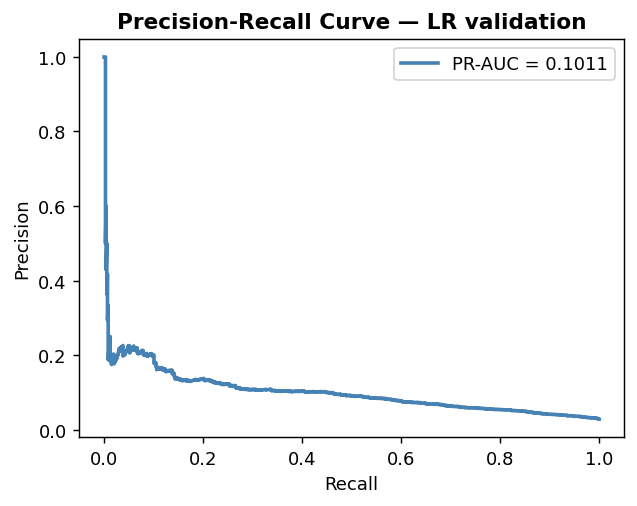

In [10]:
print("\n" + "=" * 60)
print("8. LOGISTIC REGRESSION")
print("=" * 60)

lr_param_grid = {"C": [0.1, 0.5, 1.0]}

print(f"Grid search: C in {lr_param_grid['C']}")
print("This runs 3-fold CV x 3 values = 9 fits...")

lr_gs = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=SEED
    ),
    param_grid=lr_param_grid,
    scoring=f1_fake_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True
)
lr_gs.fit(X_train, y_train)

print(f"\nGrid search results:")
cv_results = pd.DataFrame(lr_gs.cv_results_)
for _, row in cv_results[["param_C", "mean_test_score",
                            "std_test_score"]].iterrows():
    print(f"  C={row['param_C']:.2f} -> "
          f"CV F1={row['mean_test_score']:.4f} "
          f"(+/-{row['std_test_score']:.4f})")

print(f"\nBest params : {lr_gs.best_params_}")
print(f"Best CV F1  : {lr_gs.best_score_:.4f}")

best_lr = lr_gs.best_estimator_
joblib.dump(best_lr, MODEL_PATH + "logistic_regression.pkl")
print("Saved: logistic_regression.pkl")

# Threshold tuning on validation set
lr_val_proba          = best_lr.predict_proba(X_val)[:, 1]
lr_thresh, lr_val_f1  = tune_threshold(y_val, lr_val_proba,
                                        "Logistic Regression")

lr_val_pred = (lr_val_proba >= lr_thresh).astype(int)
print("\nValidation performance (tuned threshold — for reference):")
val_metrics_lr = print_evaluation(
    y_val, lr_val_pred, lr_val_proba,
    "LR — validation", lr_thresh
)
plot_pr_curve(y_val, lr_val_proba, "LR validation", MODEL_PATH)

# ============================================================
# 9. LIGHTGBM — HYPERPARAMETER SEARCH + TRAINING
# ============================================================

Grid: {'num_leaves': [31, 64, 128], 'learning_rate': [0.05, 0.1], 'min_child_samples': [20, 50], 'reg_lambda': [0, 1]}
Total combinations: 24
[50]	valid_0's auc: 0.751258
[100]	valid_0's auc: 0.761406
[150]	valid_0's auc: 0.762028
[200]	valid_0's auc: 0.76251
[250]	valid_0's auc: 0.760979
[300]	valid_0's auc: 0.759465

  Threshold tuning (LGBM(nl=31,lr=0.05,mcs=20,rl=0)):
    Search range   : 0.01 -> 0.99 (300 steps)
    Best threshold : 0.6975
    Best val F1    : 0.1749
  nl= 31 lr=0.05 mcs=20 rl=0 | iter= 215 | val F1=0.1749
[50]	valid_0's auc: 0.752727
[100]	valid_0's auc: 0.760207
[150]	valid_0's auc: 0.762906
[200]	valid_0's auc: 0.763417
[250]	valid_0's auc: 0.763137
[300]	valid_0's auc: 0.762528

  Threshold tuning (LGBM(nl=31,lr=0.05,mcs=20,rl=1)):
    Search range   : 0.01 -> 0.99 (300 steps)
    Best threshold : 0.7047
    Best val F1    : 0.1682
  nl= 31 lr=0.05 mcs=20 rl=1 | iter= 226 | val F1=0.1682
[50]	valid_0's auc: 0.752308
[100]	valid_0's auc: 0.761365
[150]	valid_0'

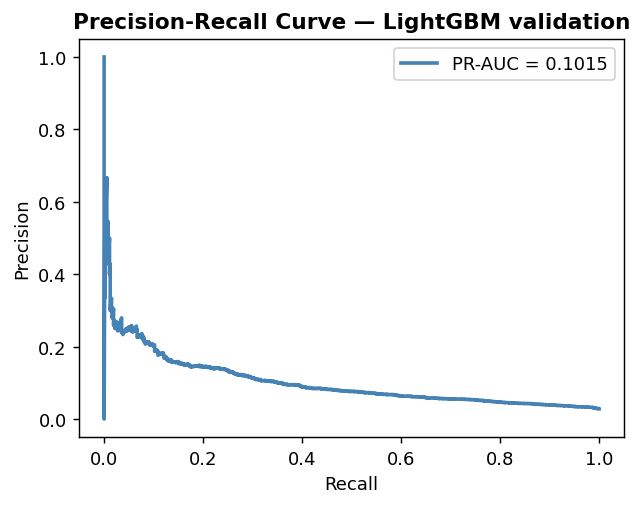

In [11]:
# Added min_child_samples and reg_lambda to match B2 grid
# for methodological consistency across experiments.
# Total combinations: 3 x 2 x 2 x 2 = 24
# ============================================================

# metric="auc" prevents early stopping triggering immediately
# on imbalanced data. stopping_rounds=100 gives enough room.
# min_child_samples: prevents overfitting on small fake class
# reg_lambda: L2 regularisation for better generalisation

lgbm_grid = {
    "num_leaves":        [31, 64, 128],
    "learning_rate":     [0.05, 0.1],
    "min_child_samples": [20, 50],
    "reg_lambda":        [0, 1],
}

n_combos = (len(lgbm_grid["num_leaves"]) *
            len(lgbm_grid["learning_rate"]) *
            len(lgbm_grid["min_child_samples"]) *
            len(lgbm_grid["reg_lambda"]))

print(f"Grid: {lgbm_grid}")
print(f"Total combinations: {n_combos}")

best_lgbm_val_f1  = 0.0
best_lgbm_params  = {}
best_lgbm         = None
best_lgbm_thresh  = 0.5
lgbm_grid_results = []

for nl in lgbm_grid["num_leaves"]:
    for lr_val in lgbm_grid["learning_rate"]:
        for mcs in lgbm_grid["min_child_samples"]:
            for rl in lgbm_grid["reg_lambda"]:

                candidate = lgb.LGBMClassifier(
                    n_estimators=1000,
                    learning_rate=lr_val,
                    max_depth=-1,
                    num_leaves=nl,
                    min_child_samples=mcs,
                    reg_lambda=rl,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=scale_pos_weight,
                    metric="auc",
                    random_state=SEED,
                    n_jobs=-1,
                    verbose=-1
                )
                candidate.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[
                        lgb.early_stopping(
                            stopping_rounds=100, verbose=False
                        ),
                        lgb.log_evaluation(period=50)
                    ]
                )

                val_proba        = candidate.predict_proba(X_val)[:, 1]
                cand_thresh, cand_f1 = tune_threshold(
                    y_val, val_proba,
                    f"LGBM(nl={nl},lr={lr_val},mcs={mcs},rl={rl})"
                )

                print(f"  nl={nl:3d} lr={lr_val:.2f} "
                      f"mcs={mcs:2d} rl={rl} | "
                      f"iter={candidate.best_iteration_:4d} | "
                      f"val F1={cand_f1:.4f}")

                lgbm_grid_results.append({
                    "num_leaves":        nl,
                    "learning_rate":     lr_val,
                    "min_child_samples": mcs,
                    "reg_lambda":        rl,
                    "best_iter":         candidate.best_iteration_,
                    "val_f1":            round(cand_f1,     4),
                    "threshold":         round(cand_thresh, 4),
                })

                if cand_f1 > best_lgbm_val_f1:
                    best_lgbm_val_f1 = cand_f1
                    best_lgbm_params = {
                        "num_leaves":        nl,
                        "learning_rate":     lr_val,
                        "min_child_samples": mcs,
                        "reg_lambda":        rl,
                    }
                    best_lgbm        = candidate
                    best_lgbm_thresh = cand_thresh

print(f"\nBest LGBM params : {best_lgbm_params}")
print(f"Best LGBM val F1 : {best_lgbm_val_f1:.4f}")
print(f"Best threshold   : {best_lgbm_thresh:.4f}")

lgbm_grid_df = pd.DataFrame(lgbm_grid_results)
print("\nFull grid results:")
print(lgbm_grid_df.to_string(index=False))

joblib.dump(best_lgbm, MODEL_PATH + "lightgbm.pkl")
print("\nSaved: lightgbm.pkl")

lgbm_val_proba = best_lgbm.predict_proba(X_val)[:, 1]
lgbm_val_pred  = (lgbm_val_proba >= best_lgbm_thresh).astype(int)
print("\nValidation performance (tuned threshold — for reference):")
val_metrics_lgbm = print_evaluation(
    y_val, lgbm_val_pred, lgbm_val_proba,
    "LightGBM — validation", best_lgbm_thresh
)
plot_pr_curve(y_val, lgbm_val_proba, "LightGBM validation", MODEL_PATH)

# ============================================================
# 10. SAVE THRESHOLDS AND VALIDATION RESULTS
# ============================================================

In [13]:
print("\n" + "=" * 60)
print("10. SAVING THRESHOLDS AND VALIDATION RESULTS")
print("=" * 60)

thresholds = {
    "lr":   lr_thresh,
    "lgbm": best_lgbm_thresh,
}
joblib.dump(thresholds, MODEL_PATH + "thresholds.pkl")
print(f"Saved thresholds : {thresholds}")

val_results_df = pd.DataFrame([val_metrics_lr, val_metrics_lgbm])
val_results_df.to_csv(MODEL_PATH + "results_validation_b1.csv",
                      index=False)
lgbm_grid_df.to_csv(MODEL_PATH + "lgbm_grid_results_b1.csv",
                    index=False)
print("Saved: results_validation_b1.csv")
print("Saved: lgbm_grid_results_b1.csv")


10. SAVING THRESHOLDS AND VALIDATION RESULTS
Saved thresholds : {'lr': 0.6542084168336673, 'lgbm': 0.7029058116232465}
Saved: results_validation_b1.csv
Saved: lgbm_grid_results_b1.csv


# ============================================================
# 11. FINAL TEST EVALUATION
# ============================================================


11. FINAL TEST EVALUATION

───────────────────────────────────────────────────────
  Logistic Regression — test  (threshold = 0.654)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.8775
  F1 macro         : 0.5436
  F1 weighted      : 0.9118
  ROC-AUC          : 0.7612
  PR-AUC           : 0.1039
  -- Genuine class --
  Precision        : 0.9804
  Recall           : 0.8917
  F1-score         : 0.9339
  -- Fake class --
  Precision        : 0.0954
  Recall           : 0.3905
  F1-score         : 0.1534

Classification report:
              precision    recall  f1-score   support

 Genuine (0)     0.9804    0.8917    0.9339     25124
    Fake (1)     0.0954    0.3905    0.1534       735

    accuracy                         0.8775     25859
   macro avg     0.5379    0.6411    0.5436     25859
weighted avg     0.9552    0.8775    0.9118     25859



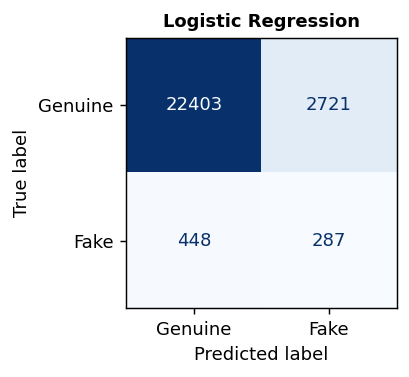

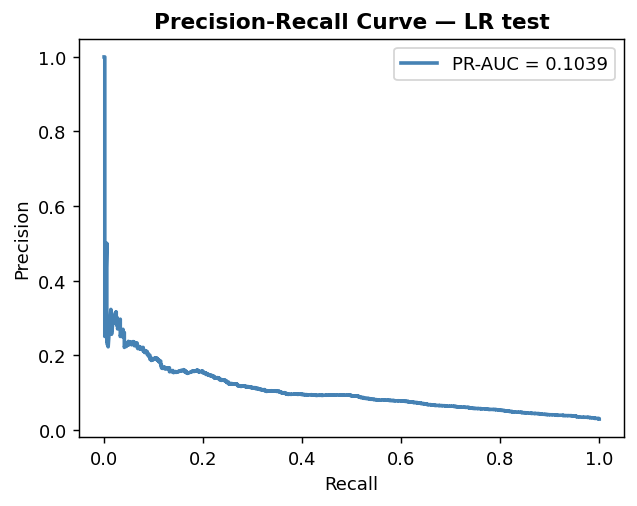


───────────────────────────────────────────────────────
  LightGBM — test  (threshold = 0.703)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.9423
  F1 macro         : 0.5752
  F1 weighted      : 0.9477
  ROC-AUC          : 0.7581
  PR-AUC           : 0.1211
  -- Genuine class --
  Precision        : 0.9770
  Recall           : 0.9634
  F1-score         : 0.9701
  -- Fake class --
  Precision        : 0.1513
  Recall           : 0.2231
  F1-score         : 0.1803

Classification report:
              precision    recall  f1-score   support

 Genuine (0)     0.9770    0.9634    0.9701     25124
    Fake (1)     0.1513    0.2231    0.1803       735

    accuracy                         0.9423     25859
   macro avg     0.5641    0.5933    0.5752     25859
weighted avg     0.9535    0.9423    0.9477     25859



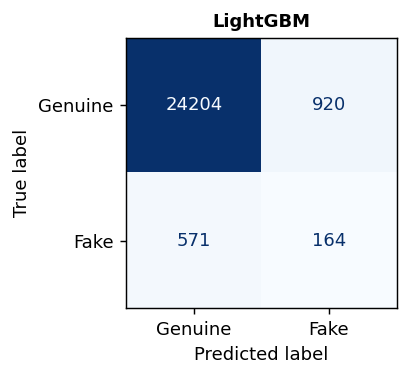

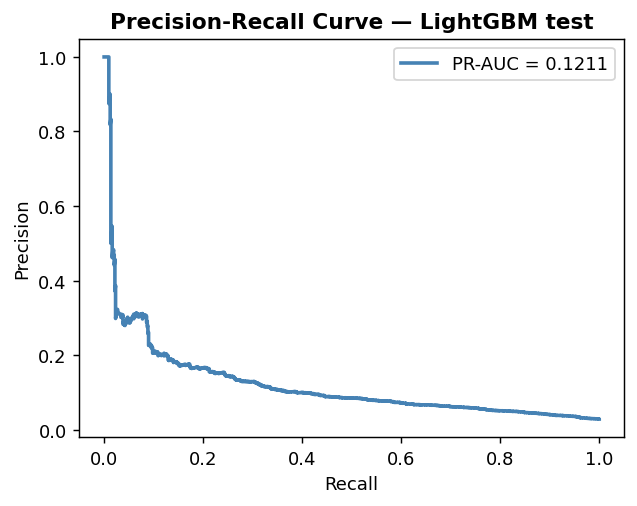

In [14]:
# Test set touched ONCE — right here.
# Thresholds from validation applied directly.
# Nothing re-tuned after seeing test results.
# ============================================================
print("\n" + "=" * 60)
print("11. FINAL TEST EVALUATION")
print("=" * 60)

all_results = []

# ── Logistic Regression on test ──────────────────────────────
lr_test_proba = best_lr.predict_proba(X_test)[:, 1]
lr_test_pred  = (lr_test_proba >= lr_thresh).astype(int)

metrics_lr = print_evaluation(
    y_test, lr_test_pred, lr_test_proba,
    "Logistic Regression — test", lr_thresh
)
plot_confusion(y_test, lr_test_pred,
               "Logistic Regression", MODEL_PATH)
plot_pr_curve(y_test, lr_test_proba,
              "LR test", MODEL_PATH)
all_results.append(metrics_lr)

# ── LightGBM on test ─────────────────────────────────────────
lgbm_test_proba = best_lgbm.predict_proba(X_test)[:, 1]
lgbm_test_pred  = (lgbm_test_proba >= best_lgbm_thresh).astype(int)

metrics_lgbm = print_evaluation(
    y_test, lgbm_test_pred, lgbm_test_proba,
    "LightGBM — test", best_lgbm_thresh
)
plot_confusion(y_test, lgbm_test_pred,
               "LightGBM", MODEL_PATH)
plot_pr_curve(y_test, lgbm_test_proba,
              "LightGBM test", MODEL_PATH)
all_results.append(metrics_lgbm)

# ============================================================
# 12. RESULTS TABLE
# ============================================================

In [15]:
print("\n" + "=" * 60)
print("12. RESULTS SUMMARY — EXPERIMENT B1 (TEST SET)")
print("=" * 60)
print("Filtered | TF-IDF + metadata | no behavioral features\n")

results_df = pd.DataFrame(all_results).set_index("model")
print(results_df.to_string())
print("\nNote: threshold tuned on validation set, applied once on test")

results_df.to_csv(MODEL_PATH + "results_experiment_b1.csv")
print(f"\nSaved: results_experiment_b1.csv")


12. RESULTS SUMMARY — EXPERIMENT B1 (TEST SET)
Filtered | TF-IDF + metadata | no behavioral features

                            threshold  accuracy  f1_macro  f1_weighted  roc_auc  pr_auc  precision_gen  recall_gen  f1_gen  precision_fake  recall_fake  f1_fake
model                                                                                                                                                           
Logistic Regression — test      0.654    0.8775    0.5436       0.9118   0.7612  0.1039         0.9804      0.8917  0.9339          0.0954       0.3905   0.1534
LightGBM — test                 0.703    0.9423    0.5752       0.9477   0.7581  0.1211         0.9770      0.9634  0.9701          0.1513       0.2231   0.1803

Note: threshold tuned on validation set, applied once on test

Saved: results_experiment_b1.csv


# ============================================================
# 13. SUMMARY
# ============================================================

In [16]:
print("\n" + "=" * 60)
print("EXPERIMENT B1 COMPLETE")
print("=" * 60)
print(f"""
Dataset  : yelp_nyc_processed_v2.csv → filtered (threshold > 3)
  Unfiltered : {len(df_full):,} reviews
  Filtered   : {len(df):,} reviews
  Fake lost  : {fake_lost:,} ({pct_lost:.1f}% of all fake reviews)

  Filtered class distribution:
  Genuine    : {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)
  Fake       : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)

Split    : 70 / 15 / 15 stratified (train / val / test)
  Train      : {len(y_train):,}
  Validation : {len(y_val):,}
  Test       : {len(y_test):,}

Features : {X_train.shape[1]} total
  TF-IDF   : {X_tfidf_train.shape[1]} (unigrams+bigrams, fit on train only)
  Metadata : {len(META_COLS)} ({META_COLS})

Imbalance: class_weight="balanced"      (LR)
           scale_pos_weight={scale_pos_weight:.4f}  (LightGBM)

Tuning   : small grid on validation set
  LR best C        : {lr_gs.best_params_['C']}
  LGBM best params : {best_lgbm_params}
  LR threshold     : {lr_thresh:.4f}
  LGBM threshold   : {best_lgbm_thresh:.4f}

Saved to : {MODEL_PATH}
  logistic_regression.pkl
  lightgbm.pkl
  tfidf_vectorizer.pkl   (+ cached npz matrices)
  meta_scaler.pkl
  thresholds.pkl
  feature_names.pkl
  idx_train / val / test .npy
  results_validation_b1.csv
  lgbm_grid_results_b1.csv
  results_experiment_b1.csv
  confusion_*.png
  pr_curve_*.png

Next     : B2 — filtered + TF-IDF + metadata + behavioral features
""")


EXPERIMENT B1 COMPLETE

Dataset  : yelp_nyc_processed_v2.csv → filtered (threshold > 3)
  Unfiltered : 359,052 reviews
  Filtered   : 172,389 reviews
  Fake lost  : 31,984 (86.7% of all fake reviews)

  Filtered class distribution:
  Genuine    : 167,488 (97.2%)
  Fake       : 4,901 (2.8%)

Split    : 70 / 15 / 15 stratified (train / val / test)
  Train      : 120,672
  Validation : 25,858
  Test       : 25,859

Features : 3006 total
  TF-IDF   : 3000 (unigrams+bigrams, fit on train only)
  Metadata : 6 (['rating', 'review_length', 'extreme_rating', 'review_month', 'review_dayofweek', 'is_weekend'])

Imbalance: class_weight="balanced"      (LR)
           scale_pos_weight=34.1711  (LightGBM)

Tuning   : small grid on validation set
  LR best C        : 0.1
  LGBM best params : {'num_leaves': 128, 'learning_rate': 0.1, 'min_child_samples': 50, 'reg_lambda': 1}
  LR threshold     : 0.6542
  LGBM threshold   : 0.7029

Saved to : /content/drive/MyDrive/FakeReviewProject/experiment_b1/mode